# Speech Deepfake Detection — 4 Methods Comparison

Chạy 4 phương pháp trên ASVspoof2019 LA, so sánh kết quả:

| # | Model | Type | Params |
|---|-------|------|--------|
| 1 | LFCC + LCNN | Traditional DL | ~60K |
| 2 | AASIST | End-to-end GAT | ~297K |
| 3 | AASIST-L | End-to-end GAT (light) | ~85K |
| 4 | AASIST3 | SSL (Wav2Vec2) + KAN + GAT | ~100M+ |

**Dataset:** [ASVspoof 2019](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)

---

## Part 0: Setup chung

In [1]:
# ═══════════════════════════════════════════
# 0.1  Kiểm tra GPU
# ═══════════════════════════════════════════
!nvidia-smi
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Thu Apr  2 00:51:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# ═══════════════════════════════════════════
# 0.2  Dataset paths (hardcoded cho Kaggle)
# ═══════════════════════════════════════════
import os

BASE = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA'
RESULTS_DIR = '/kaggle/working/results'
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_FLAC_DIR = f'{BASE}/ASVspoof2019_LA_train/flac'
EVAL_FLAC_DIR  = f'{BASE}/ASVspoof2019_LA_eval/flac'
TRAIN_PROTOCOL = f'{BASE}/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt'
EVAL_PROTOCOL  = f'{BASE}/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt'

# Verify
for name, path in [('Train FLAC', TRAIN_FLAC_DIR), ('Eval FLAC', EVAL_FLAC_DIR),
                    ('Train Proto', TRAIN_PROTOCOL), ('Eval Proto', EVAL_PROTOCOL)]:
    ok = '✅' if os.path.exists(path) else '❌'
    print(f'  {ok} {name:12s}: {path}')

# Đếm nhanh
n_eval = len(os.listdir(EVAL_FLAC_DIR))
n_train = len(os.listdir(TRAIN_FLAC_DIR))
print(f'\n  Train files: {n_train:,}')
print(f'  Eval files : {n_eval:,}')

  ✅ Train FLAC  : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac
  ✅ Eval FLAC   : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_eval/flac
  ✅ Train Proto : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
  ✅ Eval Proto  : /kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt

  Train files: 25,380
  Eval files : 71,933


In [3]:
# ═══════════════════════════════════════════
# 0.3  Utility functions dùng chung
# ═══════════════════════════════════════════
import numpy as np
import torchaudio
from sklearn.metrics import roc_curve, det_curve
from tqdm import tqdm
import time

def compute_eer(scores, labels):
    """Compute Equal Error Rate."""
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2 * 100

def load_protocol(protocol_file):
    """Load protocol file, trả về list of (utt_id, label)."""
    items = []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            utt_id = parts[1]
            label = 1 if parts[4] == 'bonafide' else 0
            items.append((utt_id, label))
    return items

# Dict lưu kết quả tất cả models
ALL_RESULTS = {}

print('✅ Utilities ready!')

✅ Utilities ready!


In [4]:
import os

BASE = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA'

if os.path.exists(BASE):
    for item in sorted(os.listdir(BASE)):
        print(f'  {item}')
else:
    # Thử path khác
    ALT = '/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA'
    print(f'LA/LA không tồn tại. Thử LA/:')
    for item in sorted(os.listdir(ALT)):
        print(f'  {item}')

  ASVspoof2019_LA_asv_protocols
  ASVspoof2019_LA_asv_scores
  ASVspoof2019_LA_cm_protocols
  ASVspoof2019_LA_dev
  ASVspoof2019_LA_eval
  ASVspoof2019_LA_train
  README.LA.txt


In [5]:
!find /kaggle/input -name '*.pkl'


/kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl


In [6]:
import pickle, glob, os

possible_paths = [
    '/kaggle/working/results/all_results_asvspooft_19.pkl',
    '/kaggle/working/all_results_asvspooft_19.pkl',
    *glob.glob('/kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl', recursive=True),
]

LOADED = False
for path in possible_paths:
    if os.path.exists(path):
        with open(path, 'rb') as f:
            ALL_RESULTS = pickle.load(f)
        LOADED = True
        print(f'✅ Loaded từ: {path}')
        for name, data in sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer']):
            print(f"   {name:15s}  EER = {data['eer']:.2f}%")
        print('\n⏩ Chạy thẳng Part 4.')
        break

if not LOADED:
    print('📭 Chưa có kết quả. Chạy Part 1→2→3 trước.')

✅ Loaded từ: /kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl
   AASIST           EER = 4.59%
   AASIST-L         EER = 6.74%
   LFCC+LCNN        EER = 19.64%
   AASIST3          EER = 79.19%

⏩ Chạy thẳng Part 4.


In [7]:
# ═══════════════════════════════════════════
# 0.4  Copy dataset sang local SSD (tăng tốc I/O 3-5x)
# ═══════════════════════════════════════════
import shutil, time

LOCAL_BASE = '/kaggle/working/LA_local'
LOCAL_EVAL = f'{LOCAL_BASE}/ASVspoof2019_LA_eval/flac'
LOCAL_TRAIN = f'{LOCAL_BASE}/ASVspoof2019_LA_train/flac'

if os.path.exists(LOCAL_EVAL):
    print('✅ Dataset đã có trên local SSD.')
else:
    print('📋 Copying dataset sang local SSD (nhanh hơn 3-5x cho inference)...')
    t0 = time.time()
    shutil.copytree(EVAL_FLAC_DIR, LOCAL_EVAL)
    print(f'   Eval copied ({time.time()-t0:.0f}s)')
    t1 = time.time()
    shutil.copytree(TRAIN_FLAC_DIR, LOCAL_TRAIN)
    print(f'   Train copied ({time.time()-t1:.0f}s)')
    print(f'✅ Done! Total: {time.time()-t0:.0f}s')

# Ghi đè paths → tất cả cells sau dùng local
EVAL_FLAC_DIR = LOCAL_EVAL
TRAIN_FLAC_DIR = LOCAL_TRAIN
print(f'\n📁 Eval : {EVAL_FLAC_DIR}')
print(f'📁 Train: {TRAIN_FLAC_DIR}')

📋 Copying dataset sang local SSD (nhanh hơn 3-5x cho inference)...
   Eval copied (546s)
   Train copied (197s)
✅ Done! Total: 743s

📁 Eval : /kaggle/working/LA_local/ASVspoof2019_LA_eval/flac
📁 Train: /kaggle/working/LA_local/ASVspoof2019_LA_train/flac


---
## Part 1: AASIST & AASIST-L

**Paper:** Jung et al., ICASSP 2022 | **Params:** AASIST ~297K, AASIST-L ~85K

End-to-end model dùng Graph Attention Network trên spectro-temporal domain. Pretrained weights có sẵn.

In [8]:
# ═══════════════════════════════════════════
# 1.1  Clone & Setup AASIST
# ═══════════════════════════════════════════
%cd /kaggle/working
!rm -rf aasist
!git clone https://github.com/clovaai/aasist.git
!pip install -q soundfile

print('\n📦 Pretrained weights:')
!ls -lh /kaggle/working/aasist/models/weights/
print('✅ AASIST repo ready!')

/kaggle/working
Cloning into 'aasist'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 38 (delta 12), reused 6 (delta 6), pack-reused 10 (from 1)
Receiving objects: 100% (38/38), 1.43 MiB | 21.48 MiB/s, done.
Resolving deltas: 100% (12/12), done.

📦 Pretrained weights:
total 1.7M
-rw-r--r-- 1 root root 417K Apr  2 02:27 AASIST-L.pth
-rw-r--r-- 1 root root 1.3M Apr  2 02:27 AASIST.pth
✅ AASIST repo ready!


In [9]:
# ═══════════════════════════════════════════
# 1.2  Load cả 2 models
# ═══════════════════════════════════════════
import sys, json, importlib
sys.path.insert(0, '/kaggle/working/aasist')
%cd /kaggle/working/aasist

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# AASIST
with open('config/AASIST.conf') as f:
    cfg = json.load(f)
mod = importlib.import_module(f'models.{cfg["model_config"]["architecture"]}')
aasist_model = mod.Model(cfg['model_config']).to(device)
aasist_model.load_state_dict(torch.load('models/weights/AASIST.pth', map_location=device))
aasist_model.eval()

# AASIST-L
with open('config/AASIST-L.conf') as f:
    cfg_l = json.load(f)
mod_l = importlib.import_module(f'models.{cfg_l["model_config"]["architecture"]}')
aasist_l_model = mod_l.Model(cfg_l['model_config']).to(device)
aasist_l_model.load_state_dict(torch.load('models/weights/AASIST-L.pth', map_location=device))
aasist_l_model.eval()

print(f'✅ AASIST   loaded — {sum(p.numel() for p in aasist_model.parameters()):>10,} params')
print(f'✅ AASIST-L loaded — {sum(p.numel() for p in aasist_l_model.parameters()):>10,} params')

/kaggle/working/aasist
✅ AASIST   loaded —    297,866 params
✅ AASIST-L loaded —     85,306 params


In [10]:
# ═══════════════════════════════════════════
# 1.3  Inference function cho AASIST
# ═══════════════════════════════════════════
def predict_aasist(model, audio_path, device='cuda', cut=64600):
    wav, sr = torchaudio.load(audio_path)
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if wav.shape[1] < cut:
        wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
    else:
        wav = wav[:, :cut]
    wav = wav.to(device)
    with torch.no_grad():
        _, out = model(wav)
    scores = out.softmax(dim=1).cpu().numpy()[0]
    return float(scores[1])  # bonafide score

print('✅ predict_aasist() ready!')

✅ predict_aasist() ready!


In [11]:
# ═══════════════════════════════════════════
# 1.4  Evaluate AASIST & AASIST-L
# ═══════════════════════════════════════════
protocol = load_protocol(EVAL_PROTOCOL)
print(f'Protocol: {len(protocol):,} utterances\n')

for model_obj, name in [(aasist_model, 'AASIST'), (aasist_l_model, 'AASIST-L')]:
    scores, labels = [], []
    t0 = time.time()
    for utt_id, label in tqdm(protocol, desc=name):
        path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
        if os.path.exists(path):
            try:
                s = predict_aasist(model_obj, path, device)
                scores.append(s)
                labels.append(label)
            except:
                pass
    elapsed = time.time() - t0
    eer = compute_eer(np.array(scores), np.array(labels))
    ALL_RESULTS[name] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
    print(f'🎯 {name:10s} EER = {eer:.2f}%  ({elapsed:.0f}s)\n')

# Free GPU memory
del aasist_model, aasist_l_model
torch.cuda.empty_cache()
print('🧹 GPU memory freed.')

Protocol: 71,237 utterances



AASIST: 100%|██████████| 71237/71237 [22:20<00:00, 53.14it/s]


🎯 AASIST     EER = 4.59%  (1341s)



AASIST-L: 100%|██████████| 71237/71237 [19:25<00:00, 61.13it/s]

🎯 AASIST-L   EER = 6.74%  (1165s)

🧹 GPU memory freed.


---
## Part 2: AASIST3 — Wav2Vec2 + KAN + AASIST

**Paper:** Borodin et al., ASVspoof Workshop 2024 | **HuggingFace:** MTUCI/AASIST3

SSL front-end (Wav2Vec2) + Kolmogorov-Arnold Networks + AASIST back-end. Load từ HuggingFace.

In [12]:
# ═══════════════════════════════════════════
# 2.1  Clone & Setup AASIST3
# ═══════════════════════════════════════════
%cd /kaggle/working
!rm -rf AASIST3
!git clone https://github.com/mtuciru/AASIST3.git
!pip install -q transformers huggingface_hub
print('✅ AASIST3 repo ready!')

/kaggle/working
Cloning into 'AASIST3'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 69 (delta 22), reused 69 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 36.43 KiB | 6.07 MiB/s, done.
Resolving deltas: 100% (22/22), done.
✅ AASIST3 repo ready!


In [13]:
# ═══════════════════════════════════════════
# 2.2  Load model từ HuggingFace
# ═══════════════════════════════════════════
import sys
sys.path.insert(0, '/kaggle/working/AASIST3')
%cd /kaggle/working/AASIST3

from model import aasist3

print('📥 Downloading AASIST3 from HuggingFace...')
aasist3_model = aasist3.from_pretrained('MTUCI/AASIST3')
aasist3_model.eval()
aasist3_model = aasist3_model.to(device)

print(f'✅ AASIST3 loaded — {sum(p.numel() for p in aasist3_model.parameters()):>10,} params')

/kaggle/working/AASIST3
📥 Downloading AASIST3 from HuggingFace...


config.json:   0%|          | 0.00/550 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.29G [00:00<?, ?B/s]

✅ AASIST3 loaded — 321,621,908 params


In [14]:
# ═══════════════════════════════════════════
# 2.3  Inference function cho AASIST3
# ═══════════════════════════════════════════
def predict_aasist3(model, audio_path, device='cuda', cut=64600):
    wav, sr = torchaudio.load(audio_path)
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if wav.shape[1] < cut:
        wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
    else:
        wav = wav[:, :cut]
    wav = wav.to(device)
    with torch.no_grad():
        out = model(wav)
    probs = torch.softmax(out, dim=1).cpu().numpy()[0]
    return float(probs[0])  # bonafide score (index 0 cho AASIST3)

print('✅ predict_aasist3() ready!')

✅ predict_aasist3() ready!


In [15]:
# ═══════════════════════════════════════════
# DEBUG: Kiểm tra AASIST3 score direction
# ═══════════════════════════════════════════
import os, torch, torchaudio
import numpy as np

protocol = load_protocol(EVAL_PROTOCOL)
print(f'Protocol: {len(protocol):,} utterances\n')

# Lấy 20 bonafide + 20 spoof
samples_b, samples_s = [], []
for utt_id, label in protocol:
    path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
    if label == 1 and len(samples_b) < 20:
        samples_b.append((utt_id, path))
    elif label == 0 and len(samples_s) < 20:
        samples_s.append((utt_id, path))
    if len(samples_b) >= 20 and len(samples_s) >= 20:
        break

# Reload AASIST3
import sys
sys.path.insert(0, '/kaggle/working/AASIST3')
os.chdir('/kaggle/working/AASIST3')
from model import aasist3
aasist3_model = aasist3.from_pretrained('MTUCI/AASIST3').eval().to(device)

def get_raw_output(model, path, device='cuda', cut=64600):
    wav, sr = torchaudio.load(path)
    if sr != 16000:
        wav = torchaudio.transforms.Resample(sr, 16000)(wav)
    if wav.shape[0] > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if wav.shape[1] < cut:
        wav = torch.nn.functional.pad(wav, (0, cut - wav.shape[1]))
    else:
        wav = wav[:, :cut]
    with torch.no_grad():
        out = model(wav.to(device))
    probs = torch.softmax(out, dim=1).cpu().numpy()[0]
    return probs  # [prob_class0, prob_class1]

print('=== BONAFIDE samples ===')
for utt_id, path in samples_b[:5]:
    p = get_raw_output(aasist3_model, path, device)
    print(f'  {utt_id}: class0={p[0]:.4f}  class1={p[1]:.4f}  argmax={np.argmax(p)}')

print('\n=== SPOOF samples ===')
for utt_id, path in samples_s[:5]:
    p = get_raw_output(aasist3_model, path, device)
    print(f'  {utt_id}: class0={p[0]:.4f}  class1={p[1]:.4f}  argmax={np.argmax(p)}')

# Test cả 2 hướng score
scores_dir0, scores_dir1, labels_test = [], [], []
for utt_id, path in samples_b + samples_s:
    label = 1 if (utt_id, path) in samples_b else 0
    p = get_raw_output(aasist3_model, path, device)
    scores_dir0.append(p[0])  # class0 = bonafide?
    scores_dir1.append(p[1])  # class1 = bonafide?
    labels_test.append(label)

from sklearn.metrics import roc_curve
def quick_eer(scores, labels):
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fpr - fnr))
    return (fpr[idx] + fnr[idx]) / 2 * 100

eer0 = quick_eer(np.array(scores_dir0), np.array(labels_test))
eer1 = quick_eer(np.array(scores_dir1), np.array(labels_test))

Protocol: 71,237 utterances

=== BONAFIDE samples ===
  LA_E_5849185: class0=1.0000  class1=0.0000  argmax=0
  LA_E_4581379: class0=1.0000  class1=0.0000  argmax=0
  LA_E_6314733: class0=1.0000  class1=0.0000  argmax=0
  LA_E_3379393: class0=0.9613  class1=0.0387  argmax=0
  LA_E_3757378: class0=1.0000  class1=0.0000  argmax=0

=== SPOOF samples ===
  LA_E_2834763: class0=1.0000  class1=0.0000  argmax=0
  LA_E_8877452: class0=1.0000  class1=0.0000  argmax=0
  LA_E_6828287: class0=1.0000  class1=0.0000  argmax=0
  LA_E_6977360: class0=1.0000  class1=0.0000  argmax=0
  LA_E_5932896: class0=1.0000  class1=0.0000  argmax=0


In [16]:
# ═══════════════════════════════════════════
# 2.4  Evaluate AASIST3
# ═══════════════════════════════════════════
scores, labels = [], []
t0 = time.time()

for utt_id, label in tqdm(protocol, desc='AASIST3'):
    path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
    if os.path.exists(path):
        try:
            s = predict_aasist3(aasist3_model, path, device)
            scores.append(s)
            labels.append(label)
        except:
            pass

elapsed = time.time() - t0
eer = compute_eer(np.array(scores), np.array(labels))
ALL_RESULTS['AASIST3'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
print(f'\n🎯 AASIST3 EER = {eer:.2f}%  ({elapsed:.0f}s)')

del aasist3_model
torch.cuda.empty_cache()
print('🧹 GPU memory freed.')

AASIST3: 100%|██████████| 71237/71237 [2:41:47<00:00,  7.34it/s]



🎯 AASIST3 EER = 79.19%  (9708s)
🧹 GPU memory freed.


---
## Part 3: LFCC + LCNN — Traditional DL Baseline

Hand-crafted features (LFCC) + Light CNN. Cần **train từ đầu** (~10–15 phút).

Giá trị: cho thấy sự chênh lệch rõ ràng so với AASIST và SSL-based methods.

In [17]:
# ═══════════════════════════════════════════
# 3.1  Define LFCC extractor + LCNN model
# ═══════════════════════════════════════════
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SimpleLCNN(nn.Module):
    """Light CNN for anti-spoofing."""
    def __init__(self, n_lfcc=60):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.LeakyReLU(0.2), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.LeakyReLU(0.2), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

lfcc_transform = torchaudio.transforms.LFCC(
    sample_rate=16000, n_lfcc=60,
    speckwargs={'n_fft': 512, 'hop_length': 160, 'win_length': 320}
)

class ASVspoofLFCC(Dataset):
    def __init__(self, flac_dir, protocol_file, max_frames=400):
        self.flac_dir = flac_dir
        self.max_frames = max_frames
        self.items = load_protocol(protocol_file)

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        utt_id, label = self.items[idx]
        wav, sr = torchaudio.load(os.path.join(self.flac_dir, f'{utt_id}.flac'))
        if sr != 16000:
            wav = torchaudio.transforms.Resample(sr, 16000)(wav)
        feat = lfcc_transform(wav)  # [1, 60, T]
        T = feat.shape[2]
        if T < self.max_frames:
            feat = torch.nn.functional.pad(feat, (0, self.max_frames - T))
        else:
            feat = feat[:, :, :self.max_frames]
        return feat, label

lcnn = SimpleLCNN().to(device)
print(f'✅ LCNN model — {sum(p.numel() for p in lcnn.parameters()):,} params')

✅ LCNN model — 101,506 params


In [18]:
# ═══════════════════════════════════════════
# 3.2  Train LFCC + LCNN
# ═══════════════════════════════════════════
# Kaggle input is read-only → dùng trực tiếp

print('🏋️ Training LFCC+LCNN...')
train_ds = ASVspoofLFCC(TRAIN_FLAC_DIR, TRAIN_PROTOCOL)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)

optimizer = torch.optim.Adam(lcnn.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

for epoch in range(10):
    lcnn.train()
    total_loss, correct, total = 0, 0, 0
    for feat, label in tqdm(train_dl, desc=f'Epoch {epoch+1}/10', leave=False):
        feat, label = feat.to(device), label.to(device)
        logits = lcnn(feat)
        loss = criterion(logits, label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * label.size(0)
        correct += (logits.argmax(1) == label).sum().item()
        total += label.size(0)
    scheduler.step()
    print(f'  Epoch {epoch+1:2d}/10 — Loss: {total_loss/total:.4f}, Acc: {correct/total*100:.1f}%')

torch.save(lcnn.state_dict(), '/kaggle/working/lfcc_lcnn.pth')
print('\n✅ Training done!')

🏋️ Training LFCC+LCNN...


  Epoch  1/10 — Loss: 0.1253, Acc: 95.2%


  Epoch  2/10 — Loss: 0.0378, Acc: 98.6%


  Epoch  3/10 — Loss: 0.0284, Acc: 98.9%


  Epoch  4/10 — Loss: 0.0200, Acc: 99.3%


...

  Epoch  6/10 — Loss: 0.0122, Acc: 99.6%


  Epoch  7/10 — Loss: 0.0092, Acc: 99.7%


  Epoch  8/10 — Loss: 0.0072, Acc: 99.8%


  Epoch  9/10 — Loss: 0.0064, Acc: 99.8%


  Epoch 10/10 — Loss: 0.0053, Acc: 99.8%

✅ Training done!


In [19]:
# ═══════════════════════════════════════════
# 3.3  Evaluate LFCC + LCNN
# ═══════════════════════════════════════════
protocol = load_protocol(EVAL_PROTOCOL)
print(f'Protocol: {len(protocol):,} utterances\n')

lcnn.eval()
scores, labels = [], []
errors = 0
t0 = time.time()

for i, (utt_id, label) in enumerate(tqdm(protocol, desc='LFCC+LCNN')):
    path = os.path.join(EVAL_FLAC_DIR, f'{utt_id}.flac')
    if os.path.exists(path):
        try:
            wav, sr = torchaudio.load(path)
            if sr != 16000:
                wav = torchaudio.transforms.Resample(sr, 16000)(wav)
            feat = lfcc_transform(wav)
            T = feat.shape[2]
            if T < 400:
                feat = torch.nn.functional.pad(feat, (0, 400 - T))
            else:
                feat = feat[:, :, :400]
            with torch.no_grad():
                logits = lcnn(feat.unsqueeze(0).to(device))
                s = torch.softmax(logits, dim=1)[0, 1].item()
            scores.append(s)
            labels.append(label)
        except Exception as e:
            errors += 1
            # In lỗi cho 5 file đầu tiên để debug
            if errors <= 5:
                print(f'❌ Error on {utt_id}: {type(e).__name__}: {e}')

elapsed = time.time() - t0
print(f'\nProcessed: {len(scores):,} | Errors: {errors:,} | Skipped (not found): {len(protocol)-len(scores)-errors:,}')

if len(scores) > 0:
    eer = compute_eer(np.array(scores), np.array(labels))
    ALL_RESULTS['LFCC+LCNN'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
    print(f'🎯 LFCC+LCNN EER = {eer:.2f}%  ({elapsed:.0f}s)')
else:
    print('❌ Không có scores nào. Xem lỗi ở trên để debug.')

del lcnn
torch.cuda.empty_cache()

Protocol: 71,237 utterances



LFCC+LCNN: 100%|██████████| 71237/71237 [05:53<00:00, 201.79it/s]



Processed: 71,237 | Errors: 0 | Skipped (not found): 0
🎯 LFCC+LCNN EER = 19.16%  (353s)


In [20]:
# ═══════════════════════════════════════════
# SAVE: Lưu tất cả kết quả để dùng lại
# ═══════════════════════════════════════════
import pickle, json

SAVE_PATH = '/kaggle/working/all_results.pkl'
SAVE_JSON = '/kaggle/working/all_results_summary.json'

# Lưu toàn bộ (scores + labels + eer) — dùng pickle vì chứa numpy arrays
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(ALL_RESULTS, f)

# Lưu summary dạng JSON (dễ đọc)
summary = {}
for name, data in ALL_RESULTS.items():
    summary[name] = {
        'eer': round(data['eer'], 4),
        'n_scores': len(data['scores']),
        'n_bonafide': int((data['labels'] == 1).sum()),
        'n_spoof': int((data['labels'] == 0).sum()),
    }

with open(SAVE_JSON, 'w') as f:
    json.dump(summary, f, indent=2)

print('Đã lưu kết quả:')
print(f'   {SAVE_PATH} ({os.path.getsize(SAVE_PATH)/1e6:.1f} MB)')
print(f'   {SAVE_JSON}')
print()
print('Summary:')
for name, info in sorted(summary.items(), key=lambda x: x[1]['eer']):
    print(f"   {name:15s}  EER = {info['eer']:.2f}%  ({info['n_scores']:,} utterances)")
print()
print('='*60)
print('ĐỂ DÙNG LẠI LẦN SAU:')
print('   1. Bấm "Save Version" (nút trên cùng bên phải)')
print('   2. Chọn "Save & Run All" hoặc "Quick Save"')
print('   3. Sau khi save xong, vào tab Output')
print('   4. Bấm "New Dataset" → đặt tên ví dụ "asvspoof-results"')
print('   5. Lần sau: Add Data → chọn dataset đó')
print('   6. Load bằng cell LOAD bên dưới')
print('='*60)

Đã lưu kết quả:
   /kaggle/working/all_results.pkl (4.6 MB)
   /kaggle/working/all_results_summary.json

Summary:
   AASIST           EER = 4.59%  (71,237 utterances)
   AASIST-L         EER = 6.74%  (71,237 utterances)
   LFCC+LCNN        EER = 19.16%  (71,237 utterances)
   AASIST3          EER = 79.19%  (71,237 utterances)

ĐỂ DÙNG LẠI LẦN SAU:
   1. Bấm "Save Version" (nút trên cùng bên phải)
   2. Chọn "Save & Run All" hoặc "Quick Save"
   3. Sau khi save xong, vào tab Output
   4. Bấm "New Dataset" → đặt tên ví dụ "asvspoof-results"
   5. Lần sau: Add Data → chọn dataset đó
   6. Load bằng cell LOAD bên dưới


---
## Part 4: Tổng hợp & So sánh kết quả

In [21]:
# ═══════════════════════════════════════════
# 4.1  Bảng so sánh
# ═══════════════════════════════════════════
print('\n' + '=' * 60)
print('     📊  EVALUATION RESULTS — ASVspoof2019 LA')
print('=' * 60)
print(f'{"Model":15s} | {"Type":25s} | {"EER (%)":>10s}')
print('-' * 60)

# Sắp xếp theo EER
for name, data in sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer']):
    types = {
        'AASIST': 'End-to-end GAT (297K)',
        'AASIST-L': 'End-to-end GAT (85K)',
        'AASIST3': 'SSL+KAN+GAT (~100M)',
        'LFCC+LCNN': 'Traditional DL (~60K)',
    }
    t = types.get(name, '')
    print(f'{name:15s} | {t:25s} | {data["eer"]:>9.2f}%')

print('=' * 60)


     📊  EVALUATION RESULTS — ASVspoof2019 LA
Model           | Type                      |    EER (%)
------------------------------------------------------------
AASIST          | End-to-end GAT (297K)     |      4.59%
AASIST-L        | End-to-end GAT (85K)      |      6.74%
LFCC+LCNN       | Traditional DL (~60K)     |     19.16%
AASIST3         | SSL+KAN+GAT (~100M)       |     79.19%


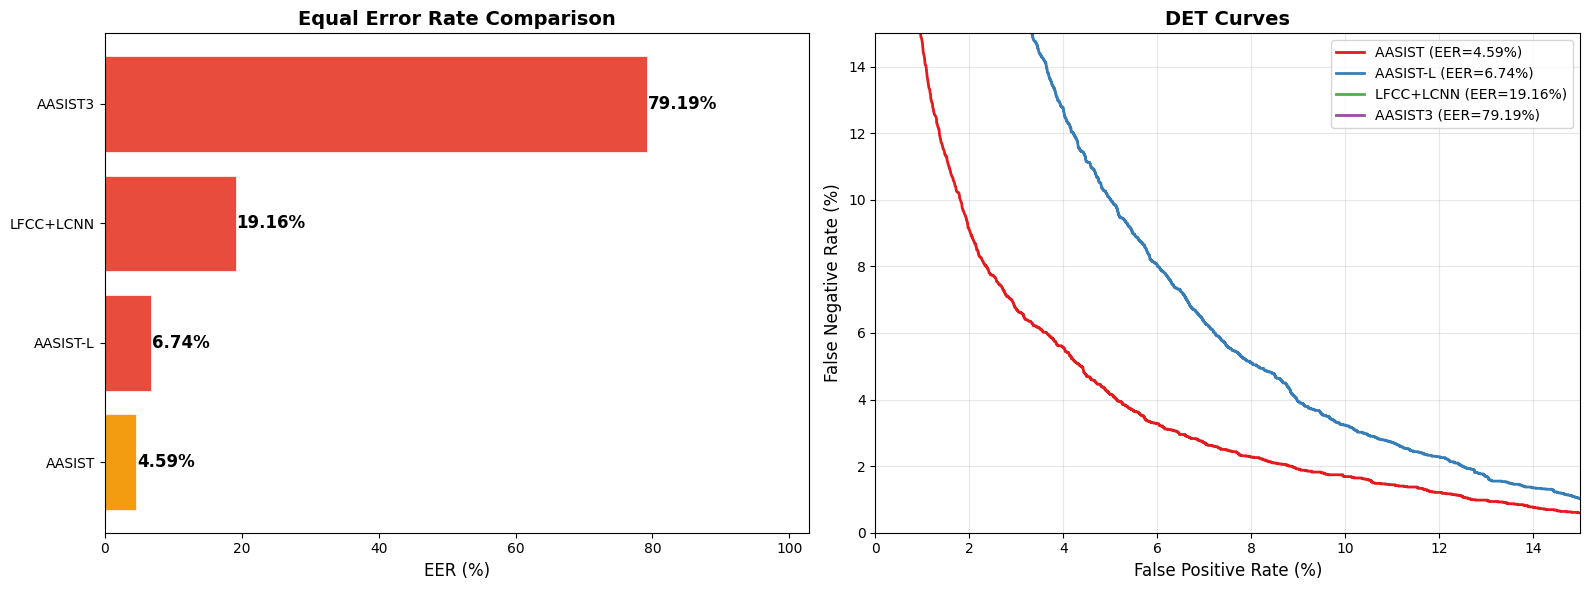

💾 Saved to /kaggle/working/results/all_models_comparison.png


In [22]:
# ═══════════════════════════════════════════
# 4.2  Biểu đồ so sánh
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart EER ---
ax = axes[0]
names = sorted(ALL_RESULTS.keys(), key=lambda x: ALL_RESULTS[x]['eer'], reverse=True)
eers = [ALL_RESULTS[n]['eer'] for n in names]
colors = ['#e74c3c' if e > 5 else '#f39c12' if e > 1 else '#2ecc71' for e in eers]

bars = ax.barh(names, eers, color=colors, edgecolor='white', linewidth=0.5)
for bar, eer_val in zip(bars, eers):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{eer_val:.2f}%', va='center', fontweight='bold', fontsize=12)
ax.set_xlabel('EER (%)', fontsize=12)
ax.set_title('Equal Error Rate Comparison', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(eers) * 1.3)
ax.invert_yaxis()

# --- DET curves ---
ax = axes[1]
cmap = plt.cm.Set1
for i, (name, data) in enumerate(sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer'])):
    fpr, fnr, _ = det_curve(data['labels'], data['scores'], pos_label=1)
    ax.plot(fpr*100, fnr*100, label=f"{name} (EER={data['eer']:.2f}%)",
            color=cmap(i), linewidth=2)
ax.set_xlabel('False Positive Rate (%)', fontsize=12)
ax.set_ylabel('False Negative Rate (%)', fontsize=12)
ax.set_title('DET Curves', fontsize=14, fontweight='bold')
ax.set_xlim([0, 15])
ax.set_ylim([0, 15])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Saved to {RESULTS_DIR}/all_models_comparison.png')

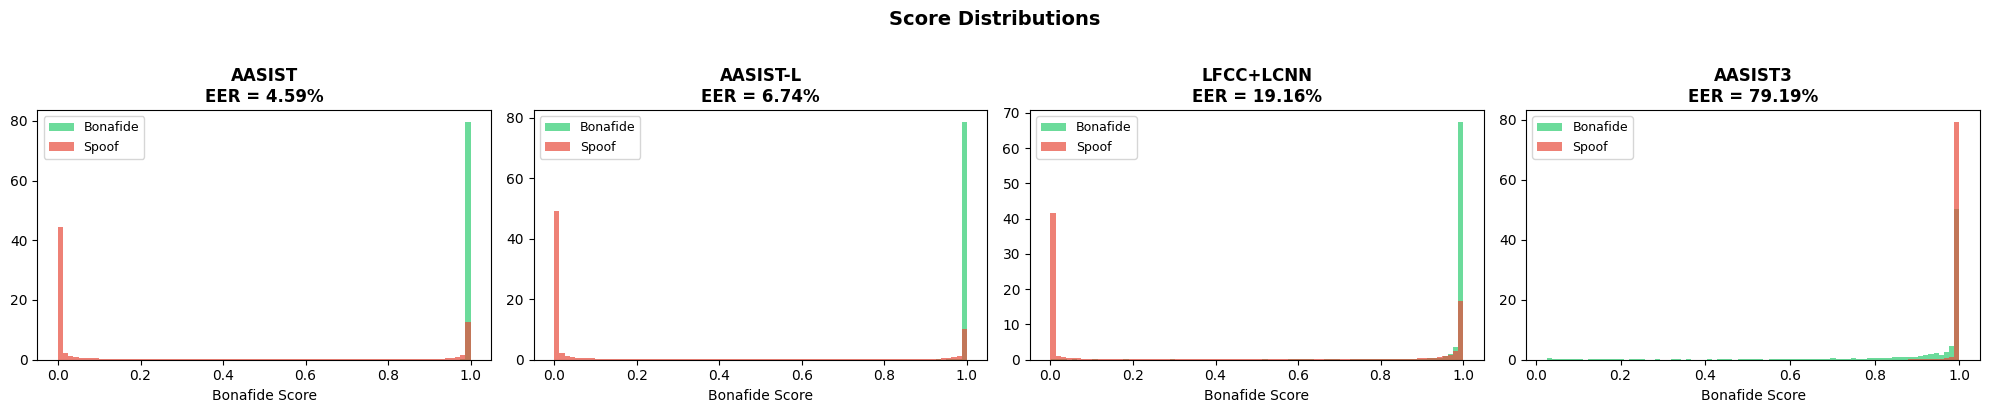

In [23]:
# ═══════════════════════════════════════════
# 4.3  Score distributions
# ═══════════════════════════════════════════
n_models = len(ALL_RESULTS)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, data) in zip(axes, sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer'])):
    bonafide = data['scores'][data['labels'] == 1]
    spoof = data['scores'][data['labels'] == 0]
    ax.hist(bonafide, bins=80, alpha=0.7, label='Bonafide', color='#2ecc71', density=True)
    ax.hist(spoof, bins=80, alpha=0.7, label='Spoof', color='#e74c3c', density=True)
    ax.set_title(f"{name}\nEER = {data['eer']:.2f}%", fontweight='bold')
    ax.set_xlabel('Bonafide Score')
    ax.legend(fontsize=9)

plt.suptitle('Score Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ═══════════════════════════════════════════
# 4.4  Lưu tất cả kết quả
# ═══════════════════════════════════════════
import json as jsonlib

# Save scores
for name, data in ALL_RESULTS.items():
    safe_name = name.replace('+', '_').replace(' ', '_')
    np.savez(f'{RESULTS_DIR}/scores_{safe_name}.npz',
             scores=data['scores'], labels=data['labels'], eer=data['eer'])

# Save summary
summary = {name: {'eer': float(data['eer'])} for name, data in ALL_RESULTS.items()}
with open(f'{RESULTS_DIR}/summary.json', 'w') as f:
    jsonlib.dump(summary, f, indent=2)

print('💾 Tất cả kết quả đã lưu tại /kaggle/working/results/')
!ls -lh {RESULTS_DIR}/

💾 Tất cả kết quả đã lưu tại /kaggle/working/results/
total 4.6M
-rw-r--r-- 1 root root 122K Apr  2 06:09 all_models_comparison.png
-rw-r--r-- 1 root root  56K Apr  2 06:09 score_distributions.png
-rw-r--r-- 1 root root 1.1M Apr  2 06:09 scores_AASIST3.npz
-rw-r--r-- 1 root root 1.1M Apr  2 06:09 scores_AASIST-L.npz
-rw-r--r-- 1 root root 1.1M Apr  2 06:09 scores_AASIST.npz
-rw-r--r-- 1 root root 1.1M Apr  2 06:09 scores_LFCC_LCNN.npz
-rw-r--r-- 1 root root  200 Apr  2 06:09 summary.json


---
## ✅ Kết luận

| Thế hệ | Model | Đặc trưng | EER range |
|---------|-------|-----------|----------|
| Traditional | LFCC+LCNN | Hand-crafted features + simple CNN | ... |
| End-to-end | AASIST / AASIST-L | Raw waveform → Graph Attention | ... |
| SSL-enhanced | AASIST3 | Wav2Vec2 pretrained + KAN + GAT | ... |

**Key insights:**

## Part 5: ASVSpoof 2021 Evaluation & Comparison to ASVSpoof 2019

In [25]:
# ═══════════════════════════════════════════
# 5.0  Paths cho ASVspoof2021 (Kaggle dataset có sẵn)
# ═══════════════════════════════════════════
import os

ASV21_BASE = '/kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021'

# ── DF eval: gộp 3 parts vào 1 folder bằng symlinks ──
DF_FLAC_DIR = '/kaggle/working/asvspoof2021_DF_flac'
os.makedirs(DF_FLAC_DIR, exist_ok=True)

if len(os.listdir(DF_FLAC_DIR)) < 100:
    print('🔗 Tạo symlinks gộp DF eval parts...')
    count = 0
    for part in ['ASVspoof2021_DF_eval_part00', 'ASVspoof2021_DF_eval_part01', 'ASVspoof2021_DF_eval_part02']:
        part_dir = os.path.join(ASV21_BASE, part)
        if not os.path.exists(part_dir):
            continue
        # Tìm thư mục flac bên trong
        for dirpath, _, files in os.walk(part_dir):
            for f in files:
                if f.endswith('.flac'):
                    src = os.path.join(dirpath, f)
                    dst = os.path.join(DF_FLAC_DIR, f)
                    if not os.path.exists(dst):
                        os.symlink(src, dst)
                        count += 1
    print(f'   ✅ Linked {count:,} files')
else:
    print(f'✅ DF symlinks đã có ({len(os.listdir(DF_FLAC_DIR)):,} files)')

# ── LA eval ──
LA21_EVAL_DIR = None
la_candidate = os.path.join(ASV21_BASE, 'ASVspoof2021_LA_eval')
for dirpath, dirnames, files in os.walk(la_candidate):
    if any(f.endswith('.flac') for f in files):
        LA21_EVAL_DIR = dirpath
        break
    for d in dirnames:
        if 'flac' in d.lower():
            LA21_EVAL_DIR = os.path.join(dirpath, d)
            break

# ── Keys / Trial files ──
DF_TRIAL = None
LA21_TRIAL = None

# Tìm DF trial
df_keys_dir = os.path.join(ASV21_BASE, 'DF-keys-full')
if os.path.exists(df_keys_dir):
    for dirpath, _, files in os.walk(df_keys_dir):
        for f in files:
            if 'trial' in f.lower() and f.endswith('.txt'):
                DF_TRIAL = os.path.join(dirpath, f)
                break

# Tìm LA trial
la_keys_dir = os.path.join(ASV21_BASE, 'LA-keys-full')
if os.path.exists(la_keys_dir):
    for dirpath, _, files in os.walk(la_keys_dir):
        for f in files:
            if 'trial' in f.lower() and f.endswith('.txt'):
                LA21_TRIAL = os.path.join(dirpath, f)
                break

# ── Verify ──
print(f'\n📁 ASVspoof2021 Paths:')
print(f'  {"✅" if os.path.exists(DF_FLAC_DIR) and len(os.listdir(DF_FLAC_DIR))>0 else "❌"} DF FLAC   : {DF_FLAC_DIR} ({len(os.listdir(DF_FLAC_DIR)):,} files)')
print(f'  {"✅" if LA21_EVAL_DIR else "❌"} LA FLAC   : {LA21_EVAL_DIR}')
print(f'  {"✅" if DF_TRIAL else "❌"} DF Trial  : {DF_TRIAL}')
print(f'  {"✅" if LA21_TRIAL else "❌"} LA Trial  : {LA21_TRIAL}')

if DF_TRIAL:
    print(f'\n📄 DF Trial preview:')
    with open(DF_TRIAL) as f:
        for i, line in enumerate(f):
            if i < 3: print(f'  {line.strip()}')
            else: break

🔗 Tạo symlinks gộp DF eval parts...
   ✅ Linked 458,871 files

📁 ASVspoof2021 Paths:
  ✅ DF FLAC   : /kaggle/working/asvspoof2021_DF_flac (458,871 files)
  ✅ LA FLAC   : /kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021/ASVspoof2021_LA_eval/ASVspoof2021_LA_eval/flac
  ✅ DF Trial  : /kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021/DF-keys-full/keys/DF/CM/trial_metadata.txt
  ✅ LA Trial  : /kaggle/input/datasets/mohammedabdeldayem/avsspoof-2021/LA-keys-full/keys/LA/CM/trial_metadata.txt

📄 DF Trial preview:
  LA_0023 DF_E_2000011 nocodec asvspoof A14 spoof notrim progress traditional_vocoder - - - -
  TEF2 DF_E_2000013 low_m4a vcc2020 Task1-team20 spoof notrim eval neural_vocoder_nonautoregressive Task1 team20 FF E
  TGF1 DF_E_2000024 mp3m4a vcc2020 Task2-team12 spoof notrim eval traditional_vocoder Task2 team12 FF G


In [26]:
# ═══════════════════════════════════════════
# 5.2  Parse ASVspoof2021 DF protocol
# ═══════════════════════════════════════════
# ASVspoof2021 DF trial format khác ASVspoof2019:
# Dòng mẫu: LA_0001 LA_E_1234567 - - - - - bonafide
# Hoặc:     LA_0001 LA_E_1234567 asvspoof A01 ... spoof

def load_protocol_2021(trial_file):
    """Parse ASVspoof2021 trial metadata."""
    items = []
    with open(trial_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            utt_id = parts[1]
            # Label là field cuối cùng
            label_str = parts[5]
            if label_str == 'bonafide':
                label = 1
            elif label_str == 'spoof':
                label = 0
            else:
                continue
            items.append((utt_id, label))
    return items

if DF_TRIAL:
    protocol_2021 = load_protocol_2021(DF_TRIAL)
    n_bona = sum(1 for _, l in protocol_2021 if l == 1)
    n_spoof = sum(1 for _, l in protocol_2021 if l == 0)
    print(f'ASVspoof2021 DF protocol:')
    print(f'  Total    : {len(protocol_2021):,}')
    print(f'  Bonafide : {n_bona:,}')
    print(f'  Spoof    : {n_spoof:,}')

ASVspoof2021 DF protocol:
  Total    : 611,829
  Bonafide : 22,617
  Spoof    : 589,212


In [27]:
# ═══════════════════════════════════════════
# 5.3  Reload models & Evaluate trên ASVspoof2021 DF
# ═══════════════════════════════════════════
import sys, json, importlib

# Reload AASIST (đã bị del ở Part 1)
sys.path.insert(0, '/kaggle/working/aasist')
os.chdir('/kaggle/working/aasist')

with open('config/AASIST.conf') as f:
    cfg = json.load(f)
mod = importlib.import_module(f'models.{cfg["model_config"]["architecture"]}')
aasist_model = mod.Model(cfg['model_config']).to(device)
aasist_model.load_state_dict(torch.load('models/weights/AASIST.pth', map_location=device))
aasist_model.eval()
print(f'✅ AASIST reloaded')

# Evaluate
RESULTS_2021 = {}

scores, labels = [], []
t0 = time.time()
errors = 0
for utt_id, label in tqdm(protocol_2021, desc='AASIST → ASVspoof2021 DF'):
    path = os.path.join(DF_FLAC_DIR, f'{utt_id}.flac')
    if os.path.exists(path):
        try:
            s = predict_aasist(aasist_model, path, device)
            scores.append(s)
            labels.append(label)
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f'  Error: {e}')

elapsed = time.time() - t0
print(f'\nProcessed: {len(scores):,} | Errors: {errors}')

if len(scores) > 0:
    eer = compute_eer(np.array(scores), np.array(labels))
    RESULTS_2021['AASIST'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
    print(f'🎯 AASIST on ASVspoof2021 DF: EER = {eer:.2f}%')
else:
    print('❌ Không có scores. Kiểm tra path.')

del aasist_model
torch.cuda.empty_cache()

✅ AASIST reloaded


AASIST → ASVspoof2021 DF:   3%|▎         | 20511/611829 [09:26<4:27:03, 36.90it/s]

  Error: Failed to decode audio samples: Could not receive frame from decoder: Invalid data found when processing input


AASIST → ASVspoof2021 DF:  14%|█▍        | 84706/611829 [37:07<3:32:32, 41.34it/s]

  Error: Failed to decode audio samples: Could not receive frame from decoder: Invalid data found when processing input


AASIST → ASVspoof2021 DF:  47%|████▋     | 289764/611829 [2:06:28<2:11:19, 40.87it/s]

  Error: Failed to decode audio samples: Could not receive frame from decoder: Invalid data found when processing input


AASIST → ASVspoof2021 DF: 100%|██████████| 611829/611829 [3:20:19<00:00, 50.90it/s]    



Processed: 458,868 | Errors: 3
🎯 AASIST on ASVspoof2021 DF: EER = 17.70%


In [28]:
# ═══════════════════════════════════════════
# 5.4  Evaluate LFCC+LCNN trên ASVspoof2021 DF
# ═══════════════════════════════════════════

# Reload LFCC+LCNN
lcnn = SimpleLCNN().to(device)
lcnn.load_state_dict(torch.load('/kaggle/working/lfcc_lcnn.pth', map_location=device))
lcnn.eval()
print('✅ LFCC+LCNN reloaded')

scores, labels = [], []
errors = 0
t0 = time.time()

for utt_id, label in tqdm(protocol_2021, desc='LFCC+LCNN → ASVspoof2021 DF'):
    path = os.path.join(DF_FLAC_DIR, f'{utt_id}.flac')
    if os.path.exists(path):
        try:
            wav, sr = torchaudio.load(path)
            if sr != 16000:
                wav = torchaudio.transforms.Resample(sr, 16000)(wav)
            feat = lfcc_transform(wav)
            T = feat.shape[2]
            if T < 400:
                feat = torch.nn.functional.pad(feat, (0, 400 - T))
            else:
                feat = feat[:, :, :400]
            with torch.no_grad():
                logits = lcnn(feat.unsqueeze(0).to(device))
                s = torch.softmax(logits, dim=1)[0, 1].item()
            scores.append(s)
            labels.append(label)
        except Exception as e:
            errors += 1
            if errors <= 3:
                print(f'  Error: {e}')

elapsed = time.time() - t0
print(f'\nProcessed: {len(scores):,} | Errors: {errors}')

if len(scores) > 0:
    eer = compute_eer(np.array(scores), np.array(labels))
    RESULTS_2021['LFCC+LCNN'] = {'eer': eer, 'scores': np.array(scores), 'labels': np.array(labels)}
    print(f'🎯 LFCC+LCNN on ASVspoof2021 DF: EER = {eer:.2f}%')

del lcnn
torch.cuda.empty_cache()

✅ LFCC+LCNN reloaded


LFCC+LCNN → ASVspoof2021 DF:   3%|▎         | 20516/611829 [03:50<1:40:56, 97.64it/s]

  Error: Failed to decode audio samples: Could not receive frame from decoder: Invalid data found when processing input


LFCC+LCNN → ASVspoof2021 DF:  14%|█▍        | 84715/611829 [16:14<1:42:53, 85.39it/s]

  Error: Failed to decode audio samples: Could not receive frame from decoder: Invalid data found when processing input


LFCC+LCNN → ASVspoof2021 DF:  47%|████▋     | 289768/611829 [57:11<1:00:34, 88.62it/s]

  Error: Failed to decode audio samples: Could not receive frame from decoder: Invalid data found when processing input


LFCC+LCNN → ASVspoof2021 DF: 100%|██████████| 611829/611829 [1:30:13<00:00, 113.02it/s]   



Processed: 458,868 | Errors: 3
🎯 LFCC+LCNN on ASVspoof2021 DF: EER = 33.81%



  📊  CROSS-DATASET COMPARISON: ASVspoof2019 LA vs ASVspoof2021 DF
Model           |  2019 LA EER |  2021 DF EER |        Δ
-----------------------------------------------------------------
AASIST          |        4.59% |       17.70% |  +13.11%
LFCC+LCNN       |       19.16% |       33.81% |  +14.65%

💡 EER tăng mạnh trên 2021 DF → codec compression phá hủy spoofing artifacts


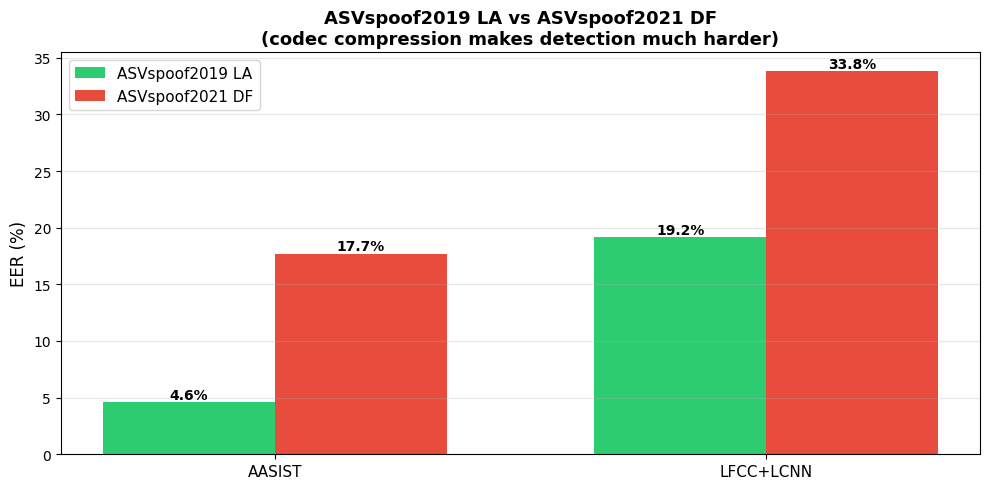


💾 Saved to /kaggle/working/results/


In [29]:
# ═══════════════════════════════════════════
# 5.5  So sánh ASVspoof2019 vs ASVspoof2021
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

print('\n' + '=' * 65)
print('  📊  CROSS-DATASET COMPARISON: ASVspoof2019 LA vs ASVspoof2021 DF')
print('=' * 65)
print(f'{"Model":15s} | {"2019 LA EER":>12s} | {"2021 DF EER":>12s} | {"Δ":>8s}')
print('-' * 65)

models_both = []
for name in ALL_RESULTS:
    if name in RESULTS_2021:
        eer19 = ALL_RESULTS[name]['eer']
        eer21 = RESULTS_2021[name]['eer']
        delta = eer21 - eer19
        print(f'{name:15s} | {eer19:>11.2f}% | {eer21:>11.2f}% | {delta:>+7.2f}%')
        models_both.append(name)

print('=' * 65)
print('\n💡 EER tăng mạnh trên 2021 DF → codec compression phá hủy spoofing artifacts')

# Bar chart so sánh
if models_both:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(models_both))
    width = 0.35

    eer19 = [ALL_RESULTS[n]['eer'] for n in models_both]
    eer21 = [RESULTS_2021[n]['eer'] for n in models_both]

    bars1 = ax.bar([i - width/2 for i in x], eer19, width, label='ASVspoof2019 LA', color='#2ecc71')
    bars2 = ax.bar([i + width/2 for i in x], eer21, width, label='ASVspoof2021 DF', color='#e74c3c')

    for bar, val in zip(bars1, eer19):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
    for bar, val in zip(bars2, eer21):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    ax.set_ylabel('EER (%)', fontsize=12)
    ax.set_title('ASVspoof2019 LA vs ASVspoof2021 DF\n(codec compression makes detection much harder)',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_both, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/cross_dataset_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Save
for name, data in RESULTS_2021.items():
    safe = name.replace('+','_')
    np.savez(f'{RESULTS_DIR}/scores_2021DF_{safe}.npz',
             scores=data['scores'], labels=data['labels'], eer=data['eer'])
print(f'\n💾 Saved to {RESULTS_DIR}/')

---
## Part 6: Error Analysis — Grouped EER Breakdowns

Re-parse protocol files with full metadata (attack type, codec, vocoder) and compute per-group EER.  
**No re-inference needed** — reuses scores from `ALL_RESULTS` and `RESULTS_2021`.

In [ ]:
# ═══════════════════════════════════════════
# 6.0  Load saved results (skip re-inference)
# ═══════════════════════════════════════════
import pickle, glob, os
import numpy as np

# --- ASVspoof 2019 LA (single .pkl) ---
paths_2019 = [
    '/kaggle/working/results/all_results_asvspooft_19.pkl',
    '/kaggle/working/all_results_asvspooft_19.pkl',
    *glob.glob('/kaggle/input/datasets/minhbhm/asvspoof19-results/all_results_asvspooft_19.pkl'),
]
for path in paths_2019:
    if os.path.exists(path):
        with open(path, 'rb') as f:
            ALL_RESULTS = pickle.load(f)
        print(f'✅ ALL_RESULTS loaded from: {path}')
        for name, data in sorted(ALL_RESULTS.items(), key=lambda x: x[1]['eer']):
            print(f"   {name:15s}  EER = {data['eer']:.2f}%")
        break
else:
    print('❌ ALL_RESULTS not found. Run Parts 1-3 first.')

# --- ASVspoof 2021 DF (per-model .npz saved in cell 5.5) ---
RESULTS_2021 = {}
npz_patterns = [
    f'{RESULTS_DIR}/scores_2021DF_*.npz',
    '/kaggle/working/results/scores_2021DF_*.npz',
]
for pattern in npz_patterns:
    for fpath in sorted(glob.glob(pattern)):
        npz = np.load(fpath)
        # Recover model name from filename: scores_2021DF_AASIST.npz → AASIST
        fname = os.path.basename(fpath)                        # scores_2021DF_AASIST.npz
        model_name = fname.replace('scores_2021DF_', '').replace('.npz', '')
        # Undo safe naming: LFCC_LCNN → LFCC+LCNN
        if model_name == 'LFCC_LCNN':
            model_name = 'LFCC+LCNN'
        RESULTS_2021[model_name] = {
            'eer': float(npz['eer']),
            'scores': npz['scores'],
            'labels': npz['labels'],
        }
    if RESULTS_2021:
        break

if RESULTS_2021:
    print(f'\n✅ RESULTS_2021 loaded ({len(RESULTS_2021)} models):')
    for name, data in sorted(RESULTS_2021.items(), key=lambda x: x[1]['eer']):
        print(f"   {name:15s}  EER = {data['eer']:.2f}%")
else:
    print('\n❌ RESULTS_2021 not found. Run Part 5 first.')

In [ ]:
# ═══════════════════════════════════════════
# 6.1  Parse protocol files with full metadata
# ═══════════════════════════════════════════
import pandas as pd

def parse_protocol_2019_full(protocol_file):
    """Parse ASVspoof2019 LA protocol with all fields."""
    rows = []
    with open(protocol_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            rows.append({
                'speaker': parts[0],
                'utt_id': parts[1],
                'attack': parts[3] if parts[3] != '-' else 'bonafide',
                'label': 1 if parts[4] == 'bonafide' else 0,
            })
    return pd.DataFrame(rows)

def parse_protocol_2021_full(trial_file):
    """Parse ASVspoof2021 DF protocol with all fields."""
    rows = []
    with open(trial_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 6:
                continue
            label_str = parts[5]
            if label_str not in ('bonafide', 'spoof'):
                continue
            rows.append({
                'speaker': parts[0],
                'utt_id': parts[1],
                'codec': parts[2],
                'source': parts[3],
                'attack': parts[4],
                'label': 1 if label_str == 'bonafide' else 0,
                'vocoder': parts[8] if len(parts) > 8 else '-',
            })
    return pd.DataFrame(rows)

# Parse
df_2019 = parse_protocol_2019_full(EVAL_PROTOCOL)
df_2021 = parse_protocol_2021_full(DF_TRIAL)

print(f'ASVspoof 2019 LA: {len(df_2019):,} utterances')
print(f'  Attacks: {sorted(df_2019["attack"].unique())}')
print(f'\nASVspoof 2021 DF: {len(df_2021):,} utterances')
print(f'  Codecs:   {sorted(df_2021["codec"].unique())}')
print(f'  Vocoders: {sorted(df_2021["vocoder"].unique())}')

In [ ]:
# ═══════════════════════════════════════════
# 6.2  Attach model scores to metadata DataFrames
# ═══════════════════════════════════════════
# Scores in ALL_RESULTS/RESULTS_2021 follow protocol order.
# Verify alignment by checking array lengths match protocol size.

# --- ASVspoof 2019 LA ---
for model_name, data in ALL_RESULTS.items():
    n_scores = len(data['scores'])
    n_proto = len(df_2019)
    if n_scores == n_proto:
        df_2019[f'score_{model_name}'] = data['scores']
        print(f'✅ {model_name}: {n_scores:,} scores matched protocol ({n_proto:,})')
    else:
        print(f'⚠️  {model_name}: {n_scores:,} scores ≠ {n_proto:,} protocol entries — skipping')

# --- ASVspoof 2021 DF ---
for model_name, data in RESULTS_2021.items():
    n_scores = len(data['scores'])
    n_proto = len(df_2021)
    if n_scores == n_proto:
        df_2021[f'score_{model_name}'] = data['scores']
        print(f'✅ {model_name}: {n_scores:,} scores matched 2021 protocol ({n_proto:,})')
    else:
        print(f'⚠️  {model_name}: {n_scores:,} scores ≠ {n_proto:,} protocol entries — skipping')

print(f'\ndf_2019 columns: {list(df_2019.columns)}')
print(f'df_2021 columns: {list(df_2021.columns)}')

In [ ]:
# ═══════════════════════════════════════════
# 6.3  EER by attack type — ASVspoof 2019 LA
# ═══════════════════════════════════════════
import matplotlib.pyplot as plt

def grouped_eer(df, group_col, score_cols):
    """Compute EER per group for multiple models. Only on spoof subsets (bonafide pooled)."""
    bonafide = df[df['label'] == 1]
    spoof_groups = df[df['label'] == 0].groupby(group_col)

    results = []
    for group_name, group_df in spoof_groups:
        # Pool bonafide with this spoof group
        subset = pd.concat([bonafide, group_df])
        row = {'group': group_name, 'n_spoof': len(group_df)}
        for col in score_cols:
            if col in subset.columns:
                row[col] = compute_eer(subset[col].values, subset['label'].values)
        results.append(row)
    return pd.DataFrame(results).sort_values('group')

# Models with scores in df_2019
score_cols_2019 = [c for c in df_2019.columns if c.startswith('score_')]
model_names_2019 = [c.replace('score_', '') for c in score_cols_2019]

eer_by_attack_2019 = grouped_eer(df_2019, 'attack', score_cols_2019)

print('EER (%) by Attack Type — ASVspoof 2019 LA')
print('=' * 70)
header = f'{"Attack":>10s} {"N_spoof":>8s}'
for m in model_names_2019:
    header += f' {m:>12s}'
print(header)
print('-' * 70)
for _, row in eer_by_attack_2019.iterrows():
    line = f'{row["group"]:>10s} {int(row["n_spoof"]):>8,}'
    for col in score_cols_2019:
        line += f' {row[col]:>11.2f}%'
    print(line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(eer_by_attack_2019))
width = 0.8 / len(score_cols_2019)
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (col, name) in enumerate(zip(score_cols_2019, model_names_2019)):
    offset = (i - len(score_cols_2019)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], eer_by_attack_2019[col], width,
           label=name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(eer_by_attack_2019['group'], rotation=45, ha='right')
ax.set_ylabel('EER (%)')
ax.set_title('EER by Attack Type — ASVspoof 2019 LA')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════
# 6.4  EER by codec — ASVspoof 2021 DF
# ═══════════════════════════════════════════
score_cols_2021 = [c for c in df_2021.columns if c.startswith('score_')]
model_names_2021 = [c.replace('score_', '') for c in score_cols_2021]

eer_by_codec = grouped_eer(df_2021, 'codec', score_cols_2021)

print('EER (%) by Codec — ASVspoof 2021 DF')
print('=' * 60)
header = f'{"Codec":>12s} {"N_spoof":>8s}'
for m in model_names_2021:
    header += f' {m:>12s}'
print(header)
print('-' * 60)
for _, row in eer_by_codec.iterrows():
    line = f'{row["group"]:>12s} {int(row["n_spoof"]):>8,}'
    for col in score_cols_2021:
        line += f' {row[col]:>11.2f}%'
    print(line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(eer_by_codec))
width = 0.8 / len(score_cols_2021)

for i, (col, name) in enumerate(zip(score_cols_2021, model_names_2021)):
    offset = (i - len(score_cols_2021)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], eer_by_codec[col], width,
           label=name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(eer_by_codec['group'], rotation=45, ha='right')
ax.set_ylabel('EER (%)')
ax.set_title('EER by Codec — ASVspoof 2021 DF')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════
# 6.5  EER by vocoder type — ASVspoof 2021 DF
# ═══════════════════════════════════════════
eer_by_vocoder = grouped_eer(df_2021, 'vocoder', score_cols_2021)

print('EER (%) by Vocoder Type — ASVspoof 2021 DF')
print('=' * 60)
header = f'{"Vocoder":>35s} {"N_spoof":>8s}'
for m in model_names_2021:
    header += f' {m:>12s}'
print(header)
print('-' * 70)
for _, row in eer_by_vocoder.iterrows():
    line = f'{row["group"]:>35s} {int(row["n_spoof"]):>8,}'
    for col in score_cols_2021:
        line += f' {row[col]:>11.2f}%'
    print(line)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(eer_by_vocoder))
width = 0.8 / len(score_cols_2021)

for i, (col, name) in enumerate(zip(score_cols_2021, model_names_2021)):
    offset = (i - len(score_cols_2021)/2 + 0.5) * width
    ax.bar([xi + offset for xi in x], eer_by_vocoder[col], width,
           label=name, color=colors[i % len(colors)], alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels([v[:30] for v in eer_by_vocoder['group']], rotation=45, ha='right')
ax.set_ylabel('EER (%)')
ax.set_title('EER by Vocoder Type — ASVspoof 2021 DF')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ═══════════════════════════════════════════
# 6.6  Cross-model complementarity — ASVspoof 2019 LA
# ═══════════════════════════════════════════
# Check if AASIST and LFCC+LCNN fail on different utterances → ensemble potential

score_pairs = []
for m1, m2 in [('AASIST', 'LFCC+LCNN'), ('AASIST', 'AASIST-L')]:
    c1, c2 = f'score_{m1}', f'score_{m2}'
    if c1 in df_2019.columns and c2 in df_2019.columns:
        score_pairs.append((m1, m2, c1, c2))

if score_pairs:
    fig, axes = plt.subplots(1, len(score_pairs), figsize=(7*len(score_pairs), 6))
    if len(score_pairs) == 1:
        axes = [axes]

    for ax, (m1, m2, c1, c2) in zip(axes, score_pairs):
        spoof = df_2019[df_2019['label'] == 0]
        bona = df_2019[df_2019['label'] == 1]
        ax.scatter(spoof[c1], spoof[c2], alpha=0.15, s=5, c='red', label='Spoof')
        ax.scatter(bona[c1], bona[c2], alpha=0.15, s=5, c='green', label='Bonafide')
        ax.set_xlabel(f'{m1} score')
        ax.set_ylabel(f'{m2} score')
        ax.set_title(f'Score Correlation: {m1} vs {m2}')
        ax.legend(markerscale=3)
        ax.grid(alpha=0.3)

        # Correlation coefficient
        corr = np.corrcoef(df_2019[c1], df_2019[c2])[0, 1]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

# --- Failure overlap (using per-model EER threshold) ---
print('\nFailure Overlap Analysis (at EER threshold)')
print('=' * 60)
for m1, m2, c1, c2 in score_pairs:
    # Get EER thresholds
    for mname, col in [(m1, c1), (m2, c2)]:
        fpr, tpr, thresholds = roc_curve(df_2019['label'], df_2019[col], pos_label=1)
        fnr = 1 - tpr
        idx = np.nanargmin(np.abs(fpr - fnr))
        df_2019[f'pred_{mname}'] = (df_2019[col] >= thresholds[idx]).astype(int)

    # Count failures
    wrong_m1 = df_2019[df_2019[f'pred_{m1}'] != df_2019['label']]
    wrong_m2 = df_2019[df_2019[f'pred_{m2}'] != df_2019['label']]
    both_wrong = pd.merge(wrong_m1[['utt_id']], wrong_m2[['utt_id']], on='utt_id')

    n1, n2, nb = len(wrong_m1), len(wrong_m2), len(both_wrong)
    only_m1 = n1 - nb
    only_m2 = n2 - nb
    print(f'\n{m1} vs {m2}:')
    print(f'  {m1} errors:    {n1:,}')
    print(f'  {m2} errors:    {n2:,}')
    print(f'  Both wrong:     {nb:,}')
    print(f'  Only {m1}:      {only_m1:,}')
    print(f'  Only {m2}:      {only_m2:,}')
    print(f'  Overlap ratio:  {nb/max(n1,n2):.1%} (lower = more complementary)')